In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

df = pd.read_csv(data)

In [3]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [4]:
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

df = df[columns]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


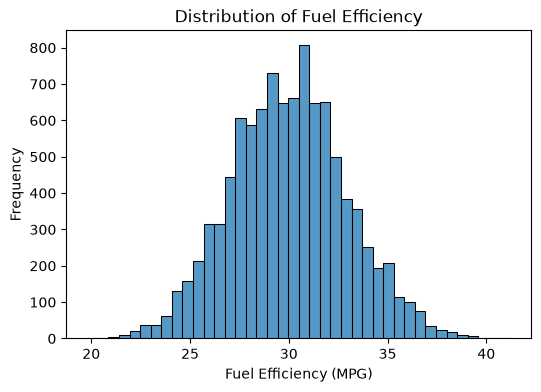

In [5]:
plt.figure(figsize=(6, 4))

sns.histplot(df.fuel_efficiency_mpg, bins=40)

plt.ylabel('Frequency')
plt.xlabel('Fuel Efficiency (MPG)')
plt.title('Distribution of Fuel Efficiency')

plt.show()

In [6]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Question 1

The column with missing values is **`horsepower`**, with 877 missing values.

**Answer: `horsepower`**

In [7]:
df.horsepower.median()

np.float64(254.0)

In [8]:
df.horsepower.describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

### Question 2

The median (50th percentile) of `horsepower` is **254**.

**Answer: 254**

In [9]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [10]:
print("Total:", n)
print("Train:", len(df_train))
print("Validation:", len(df_val))
print("Test:", len(df_test))
print("Sum:", len(df_train) + len(df_val) + len(df_test))

Total: 10000
Train: 6000
Validation: 2000
Test: 2000
Sum: 10000


In [11]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [12]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [13]:
def rmse(y, y_pred):
    error = y_pred - y
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [14]:
features = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]

In [15]:
X_train_zero = df_train[features].fillna(0).values
X_val_zero = df_val[features].fillna(0).values

w_0, w = train_linear_regression(X_train_zero, y_train)

y_pred_zero = w_0 + X_val_zero.dot(w)

rmse_zero = rmse(y_val, y_pred_zero)

print("RMSE with 0:", round(rmse_zero, 3))

RMSE with 0: 2.205


In [16]:
mean_hp = df_train.horsepower.mean()
mean_hp

np.float64(254.46338337605272)

In [17]:
X_train_mean = df_train[features].fillna({'horsepower': mean_hp}).values
X_val_mean = df_val[features].fillna({'horsepower': mean_hp}).values

w_0, w = train_linear_regression(X_train_mean, y_train)

y_pred_mean = w_0 + X_val_mean.dot(w)

rmse_mean = rmse(y_val, y_pred_mean)

print("Training horsepower mean:", mean_hp)
print("RMSE with mean:", round(rmse_mean, 3))

Training horsepower mean: 254.46338337605272
RMSE with mean: 2.202


### Question 3

- RMSE with 0: **2.205**
- RMSE with mean: **2.202**

The mean is calculated using only the training dataset.

**Answer: With mean**

In [18]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [19]:
X_train = df_train[features].fillna(0).values
X_val = df_val[features].fillna(0).values

In [20]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)

    y_pred = w_0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(r, round(score, 4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


### Question 4

Validation RMSE:

- r = 0: **2.2053**
- r = 0.01: **2.2058**
- r = 0.1: **2.2241**
- r = 1: **2.3492**
- r = 5: **2.4094**
- r = 10: **2.4195**
- r = 100: **2.4292**

The lowest validation RMSE is **2.2053** with `r = 0`.

**Answer: 0**

In [21]:
scores = []

for seed in range(10):
    # Split sizes
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    # Shuffle using the current seed
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    # Split
    df_train_seed = df.iloc[idx[:n_train]]
    df_val_seed = df.iloc[idx[n_train:n_train + n_val]]
    df_test_seed = df.iloc[idx[n_train + n_val:]]

    # Target
    y_train_seed = df_train_seed.fuel_efficiency_mpg.values
    y_val_seed = df_val_seed.fuel_efficiency_mpg.values

    # Fill missing values with 0
    X_train_seed = df_train_seed[features].fillna(0).values
    X_val_seed = df_val_seed[features].fillna(0).values

    # Train without regularization
    w_0, w = train_linear_regression(X_train_seed, y_train_seed)

    # Validation prediction
    y_pred = w_0 + X_val_seed.dot(w)

    # RMSE
    score = rmse(y_val_seed, y_pred)
    scores.append(score)

    print(seed, round(score, 3))

0 2.239
1 2.202
2 2.163
3 2.204
4 2.202
5 2.246
6 2.27
7 2.191
8 2.217
9 2.207


In [22]:
std = np.std(scores)

print("Standard deviation:", std)
print("Rounded:", round(std, 3))

Standard deviation: 0.028781274078191175
Rounded: 0.029


### Question 5

The standard deviation of the validation RMSE scores across seeds 0–9 is:

**0.028781274078191175**

Rounded to 3 decimal places:

**Answer: 0.029**

In [23]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [24]:
df_full_train = pd.concat([df_train, df_val])

In [25]:
print("Train:", len(df_train))
print("Validation:", len(df_val))
print("Combined:", len(df_full_train))
print("Test:", len(df_test))

Train: 6000
Validation: 2000
Combined: 8000
Test: 2000


In [26]:
X_full_train = df_full_train[features].fillna(0).values
X_test = df_test[features].fillna(0).values

y_full_train = df_full_train.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [27]:
w_0, w = train_linear_regression_reg(
    X_full_train,
    y_full_train,
    r=0.001
)

In [28]:
y_pred = w_0 + X_test.dot(w)

test_rmse = rmse(y_test, y_pred)

print("Test RMSE:", test_rmse)
print("Rounded:", round(test_rmse, 3))

Test RMSE: 2.235827747191731
Rounded: 2.236


### Question 6

Using seed 9, the training and validation datasets were combined.
Missing values were filled with 0, and the model was trained with `r = 0.001`.

- Test RMSE: **2.235827747191731**
- Rounded RMSE: **2.236**

**Answer: 2.236**